# **Capstone project: Providing data-driven suggestions for HR**

## Description and deliverables

This capstone project is an opportunity for you to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you would be able to present to future employers. One is a brief one-page summary of this project that you would present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Please consider your prior course work and select one way to achieve this given project question. Either use a regression model or machine learning model to predict whether or not an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.


# **PACE stages**


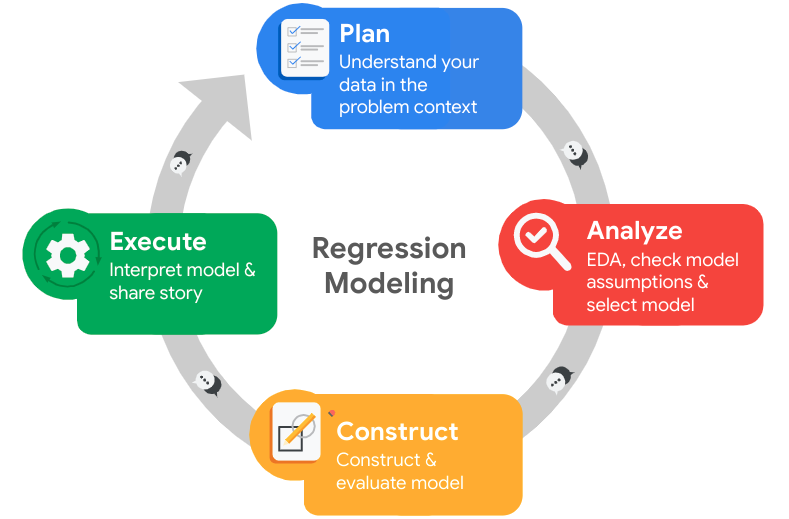

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

💭
### Reflect on these questions as you complete the plan stage.

*  Who are your stakeholders for this project?
- What are you trying to solve or accomplish?
- What are your initial observations when you explore the data?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




The stakeholders for this project are the HR department and the senior leadership team at Sailfort. They are interested in understanding why there is such a high turnover rate at their company and what can be done to reduce it.

After performing a cursory review of the basic information and descriptive statistics, I found that the dataset contained 14,999 observations with 10 columns/features. Most variables were numeric, with only two categorical features: `Department` and `Salary`. Additionally, there were no null or missing values in the data. Examination of the descriptive statistics revealed that the average employee evaluation score was very high with minimal deviation, while average satisfaction scores were slightly lower and exhibited greater variability. Approximately 2% of employees, on average, were promoted in the last five years, and employees had an average tenure of 3.5 years. Finally, there were approximately 3,008 observations identified as duplicates. Because these could cause issues later during modeling, they were removed.

The resources used during the Plan stage include the pandas documentation (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rename.html
), Stack Overflow (https://stackoverflow.com/questions/14657241/how-do-i-get-a-list-of-all-the-duplicate-items-using-pandas-in-python
), and the seaborn documentation (https://seaborn.pydata.org/generated/seaborn.boxplot.html
).

When examining the boxplots for employee tenure, I observed several outliers and decided to use the IQR method to identify them. This resulted in 824 observations being flagged as outliers in tenure. It is important not to remove outliers immediately, as doing so may lead to inaccurate conclusions that could negatively affect the objectives established by the stakeholders.

## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [28]:
# Import packages

# For data manipulation
import pandas as pd
import numpy as np

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For displaying all of the columns in dataframes
pd.set_option('display.max_columns', None)

# For data preprocessing, modeling, and metrics
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve

from xgboost import XGBClassifier
from xgboost import plot_importance
from xgboost import XGBRegressor

#For saving models
import pickle

### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [29]:
# Load dataset into a dataframe
df0 = pd.read_csv("HR_capstone_dataset.csv")


# Display first few rows of the dataframe

df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [30]:
# Gather basic information about the data
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gather descriptive statistics about the data

In [31]:
# Gather descriptive statistics about the data
df0.describe(include = 'all')

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999,14999
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4140,7316
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,NaN,NaN
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,NaN,NaN
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,NaN,NaN


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [32]:
# Display all column names
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [33]:
# Rename columns
df1 = df0.rename(columns = {'Work_accident': 'work_accident', 'Department': 'department',
                            'time_spend_company': 'tenure', 'average_montly_hours': 'average_monthly_hours'})

# Display all column names after the update
df1.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### Check missing values

Check for any missing values in the data.

In [34]:
# Check for missing values
df1.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [35]:
# Check for duplicates
df1.duplicated().sum()

3008

In [36]:
# Inspect some rows containing duplicates as needed
duplicates = df1[df1.duplicated(keep = 'first')]
duplicates

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [37]:
# Drop duplicates and save resulting dataframe in a new variable as needed
df2 = df1.drop_duplicates(keep = 'first')

# Display first few rows of new dataframe as needed
df2.head(), df2.shape

(   satisfaction_level  last_evaluation  number_project  average_monthly_hours  \
 0                0.38             0.53               2                    157   
 1                0.80             0.86               5                    262   
 2                0.11             0.88               7                    272   
 3                0.72             0.87               5                    223   
 4                0.37             0.52               2                    159   
 
    tenure  work_accident  left  promotion_last_5years department  salary  
 0       3              0     1                      0      sales     low  
 1       6              0     1                      0      sales  medium  
 2       4              0     1                      0      sales  medium  
 3       5              0     1                      0      sales     low  
 4       3              0     1                      0      sales     low  ,
 (11991, 10))

### Check outliers

Check for outliers in the data.

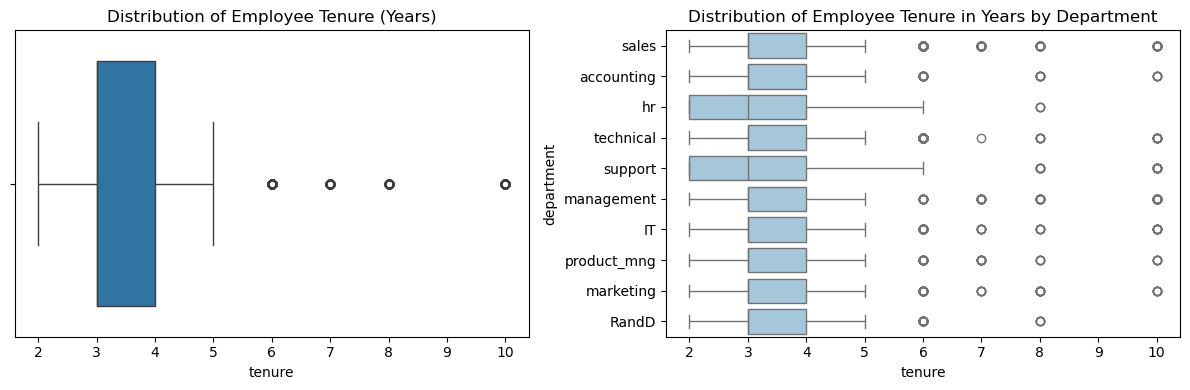

In [38]:
# Create a boxplot to visualize distribution of `tenure` and detect any outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x = df2['tenure'], ax = axes[0])
axes[0].set_title('Distribution of Employee Tenure (Years)')

sns.boxplot(x = df2['tenure'], y = df2['department'], color="#9ecae1", ax = axes[1])
axes[1].set_title('Distribution of Employee Tenure in Years by Department')

plt.tight_layout()
plt.show()

Both boxplots show outliers within the `tenure` column. It would be necessary to investigate how many rows have outliers in the `tenure` column. Additionally, this does not show any discernable difference in `tenure` by `department`.

In [39]:
# Determine the number of rows containing outliers

Q1 = df2['tenure'].quantile(0.25)
Q3 = df2['tenure'].quantile(0.75)

IQR = Q3 - Q1

outlier_mask = (
    (df2['tenure'] < (Q1 - 1.5 * IQR)) |
    (df2['tenure'] > (Q3 + 1.5 * IQR))
)


In [40]:
rows_with_outlier = df2[outlier_mask]
rows_with_outlier.shape

(824, 10)

Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



💭
### Reflect on these questions as you complete the analyze stage.

- What did you observe about the relationships between variables?
- What do you observe about the distributions in the data?
- What transformations did you make with your data? Why did you chose to make those decisions?
- What are some purposes of EDA before constructing a predictive model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?






Since the data was already cleaned and structured properly, there was no need to perform data transformations.

The impact of EDA prior to model construction is paramount due to its usefulness in finding relationships with the target outcome variable as well as the other features. This helps determine which variables to exlude due to multicollinearity assumptions for linear and logistic regression models as well as guiding feature selection/engineering. Finally, it helps with discovering outliers/anomolies within the datal.


Resources: 
* https://stackoverflow.com/questions/50558458/get-frequency-of-item-occurrences-in-a-column-as-percentage
* https://seaborn.pydata.org/tutorial/color_palettes.html

## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [41]:
# Get numbers of people who left vs. stayed

employees_stayed, employees_left = df2['left'].value_counts(normalize = True) * 100


# Get percentages of people who left vs. stayed

print(f"Percentage of people who left: {employees_left:.3f}%")
print(f"Percentage of people who stayed: {employees_stayed:.3f}%")

Percentage of people who left: 16.604%
Percentage of people who stayed: 83.396%


### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

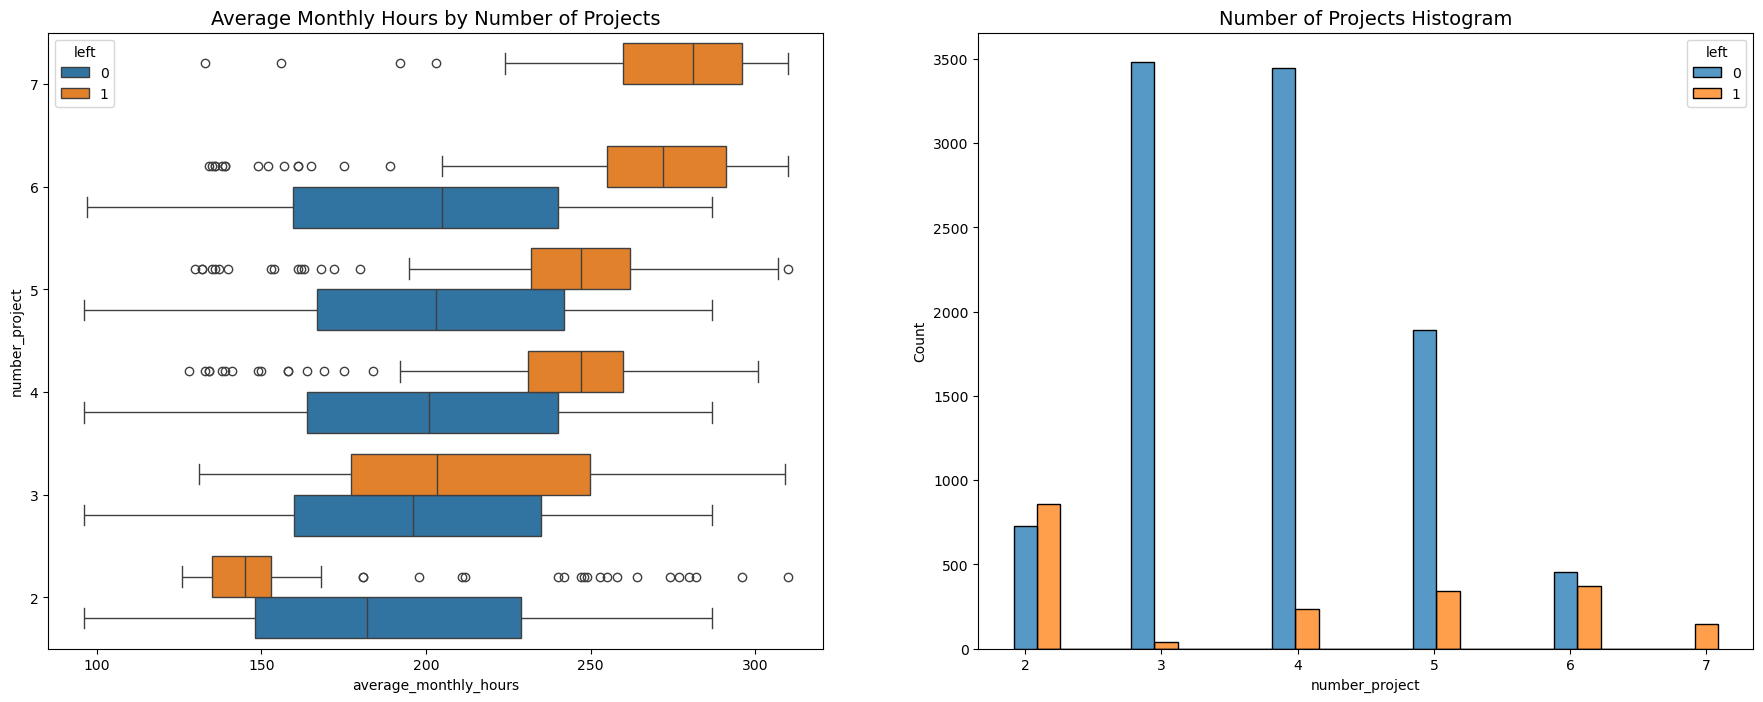

In [42]:
# Boxplot of Average Monthly Hours by Number of Projects, comparing whether they stayed versus whether they left

fig, ax = plt.subplots(1, 2, figsize = (22,8))

sns.boxplot(data = df2, x = 'average_monthly_hours', y = 'number_project', hue = 'left', orient = 'h', ax = ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Average Monthly Hours by Number of Projects', fontsize = '14')

#Histogram of Number of Projects employees contributed to, comparing whether they stayed versus whether they left
tenure_stay = df2[df2['left']==0]['number_project']
tenure_left = df2[df2['left']==1]['number_project']
sns.histplot(data=df2, x='number_project', hue='left', multiple='dodge', shrink=2, ax=ax[1])
ax[1].set_title('Number of Projects Histogram', fontsize='14')

plt.show()

There appears to be a positive relationship between Average Monthly Hours worked and Number of Projects an employee contributed, which makes sense given that the more projects you work on, the longer an employee might end up working on average. Here are some additional insights:

1. There were two types of employees who left the company: Those who worked considerably less than their peers with the same number of projects, and those who worked much more. Of those who worked considerably less, it's possible that they were fired. It's also possible that these individuals were employees who had already given their notice and were assigned fewer hours because they were already on their way out the door. For those who worked considerably more, it's reasonable to infer that they probably quit. These individuals likely contributed a lot to the projects they worked in; they might have been the largest contributors to their projects.

2. Everyone who worked on seven projects left the company, and the interquartile ranges(IQR) of this group and those who left with six projects was approximately 255–295 hours per month—much more than any other group.

3. The optimal number of projects for employees to work on seems to be 3–4. The ratio of left/stayed is very small for these cohorts.

4. Assuming a work week of 40 hours and two weeks of vacation per year, then the average number of working hours per month of employees working Monday–Friday `= 50 weeks * 40 hours per week / 12 months = 166.67 hours per month`. This means that, aside from the employees who worked on two projects, every group—even those who didn't leave the company—worked considerably more hours than this. This would likely lead to the employees being overworked.

In [43]:
# Value counts of stayed/left for employees with 7 projects
df2[df2['number_project']==7]['left'].value_counts()

left
1    145
Name: count, dtype: int64

This proves that all employees who contributed to 7 projects ended up leaving.

With this information, I want to now examine the relationship `Average Monthly Hours` has with `Satisfaction Level` and `Evaluation Score`.

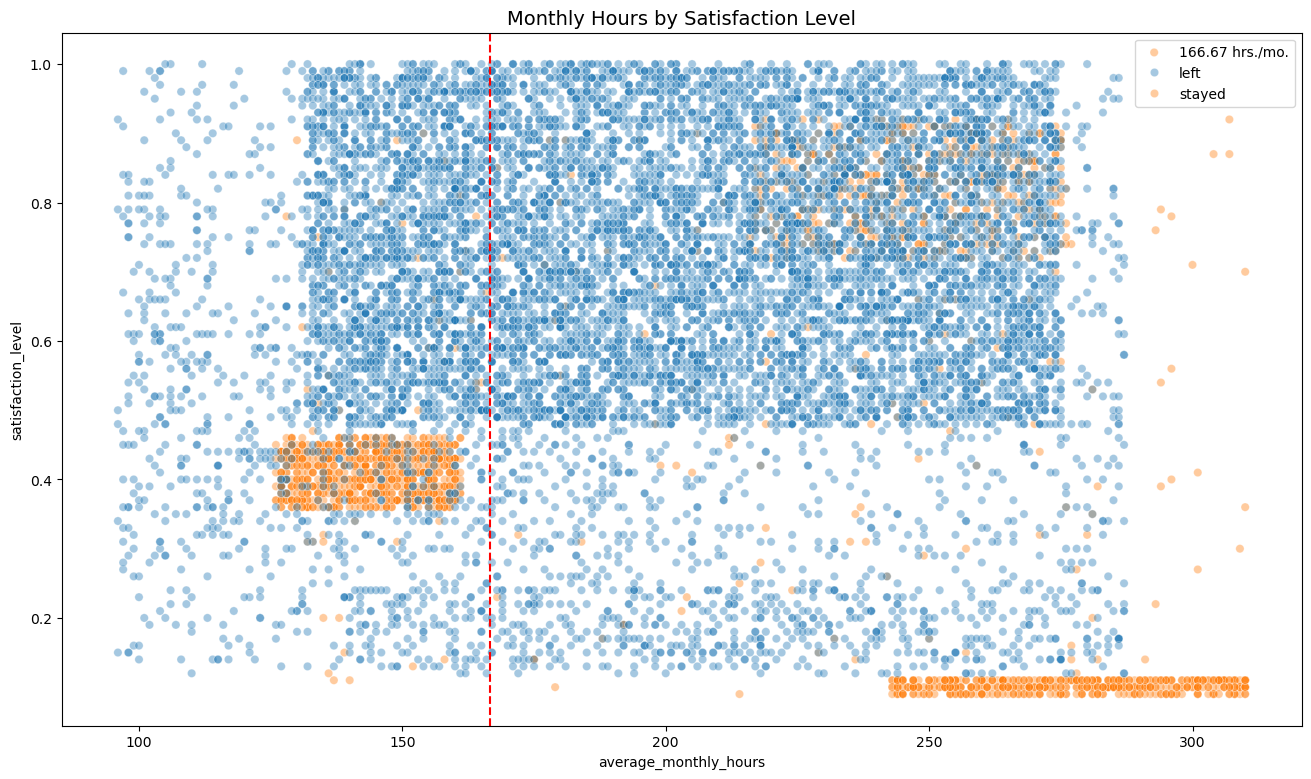

In [44]:
# Scatterplot of Average Monthly Hours an employee worked by employee Satisfaction Level
plt.figure(figsize=(16, 9))
sns.scatterplot(data=df2, x='average_monthly_hours', y='satisfaction_level', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='red', label='166.67 hrs./mo.', ls='--') #The average hours per month out side of this company: 50 weeks * 40 hours/week / 12 months = 166.67 hours/month
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly Hours by Satisfaction Level', fontsize='14');

The scatterplot above shows that there was a sizeable group of employees who worked ~240–315 hours per month. 315 hours per month is over 75 hours per week for a whole year. It's likely this is related to their satisfaction levels being close to zero.

The plot also shows another group of employees who left, those who had somewhat normal working hours. Even so, their satisfaction level was only around 0.4. It's difficult to speculate about why they might have left. It's possible they felt pressured to work more, considering so many of their peers worked more, which could have lowered their satisfaction levels.

Finally, there is a group who worked ~210–280 hours per month, and they had satisfaction levels ranging ~0.7–0.9.

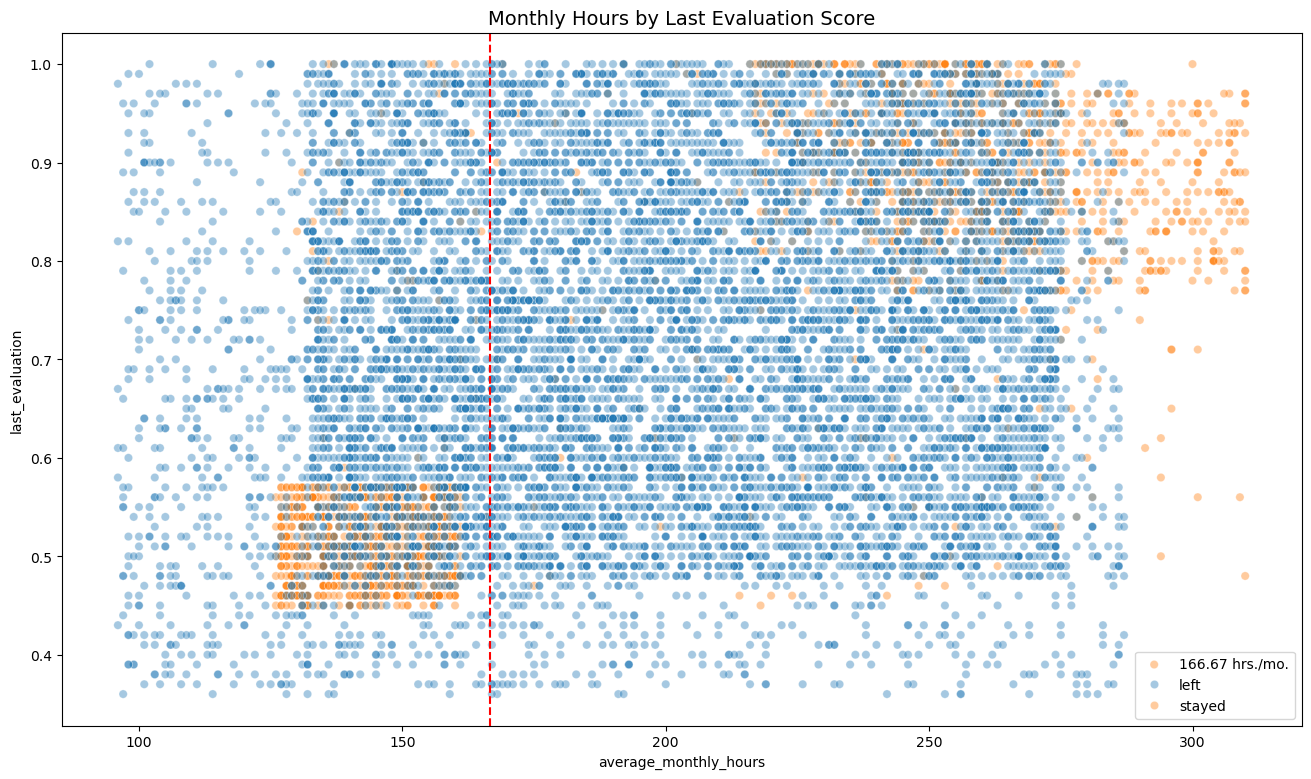

In [45]:
#Scatterplot of Average Monthly Hours an employee worked by employee's last performance evaluation
plt.figure(figsize=(16, 9))
sns.scatterplot(data=df2, x='average_monthly_hours', y='last_evaluation', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='red', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly Hours by Last Evaluation Score', fontsize='14');

The following observations can be made from the scatterplot above:

- The scatterplot indicates two groups of employees who left: overworked employees who performed very well and employees who worked slightly under the previously calculated monthly average of 166.67 hours with lower evaluation scores.

- There seems to be a correlation between `Average Monthly Hours` worked and `Evaluation Score`.

- Most of the employees in this company work well over 167 hours per month.

Now, I would like to examine `Satisfaction Level` and its relationship with `Tenure`

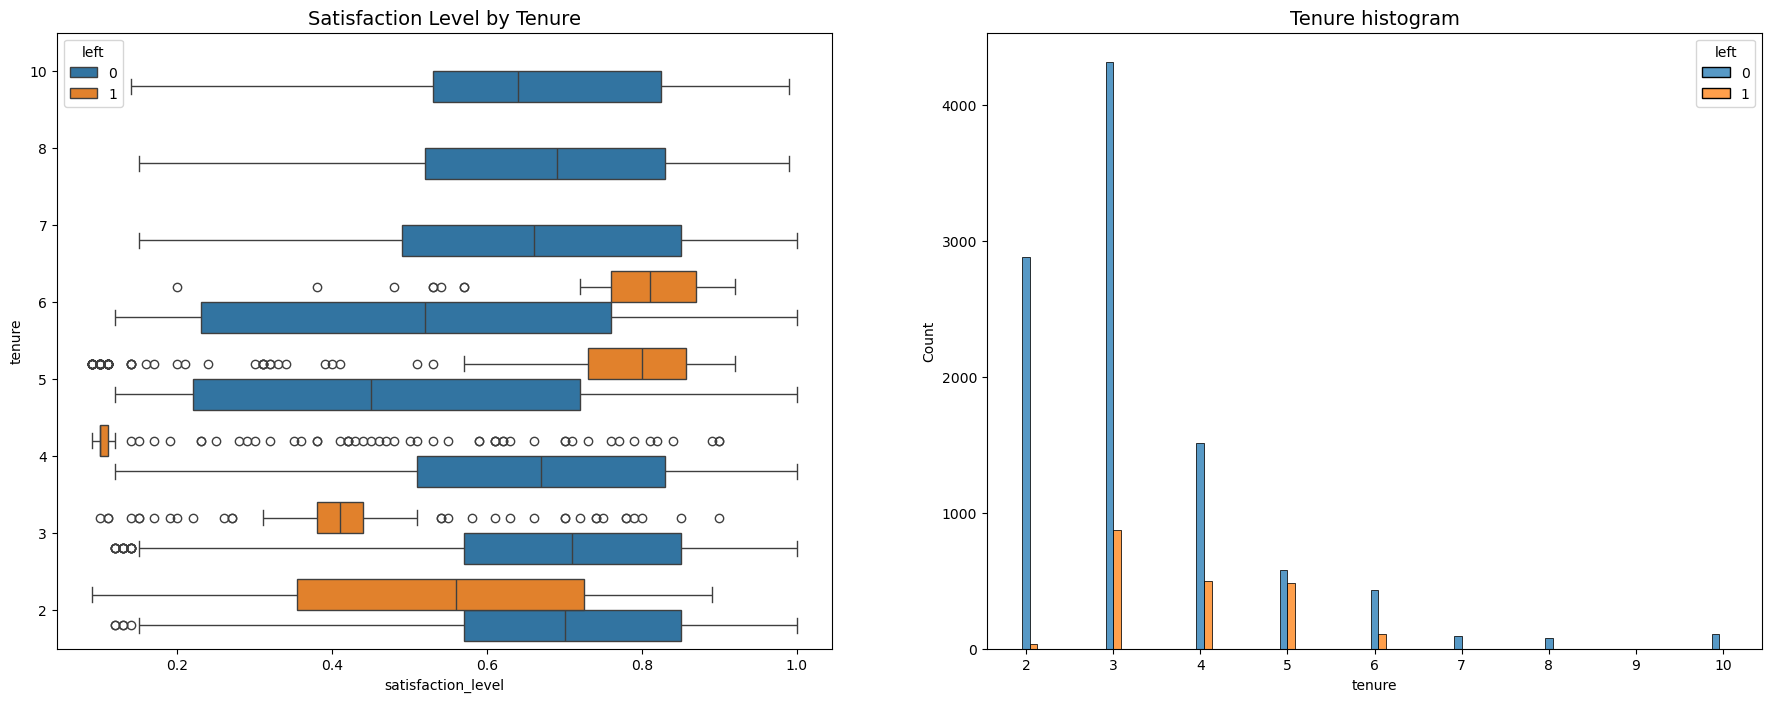

In [46]:
fig, ax = plt.subplots(1, 2, figsize = (22,8))
# Boxplot of Satisfaction Level by Tenure, comparing employees who stayed versus those who left
sns.boxplot(data = df2, x = 'satisfaction_level', y = 'tenure', hue = 'left', orient = 'h', ax = ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Satisfaction Level by Tenure', fontsize = '14')

# Histogram showing distribution of employee Tenure, comparing employees who stayed versus those who left
tenure_stay = df2[df2['left']==0]['number_project']
tenure_left = df2[df2['left']==1]['number_project']
sns.histplot(data=df2, x='tenure', hue='left', multiple='dodge', shrink=2, ax=ax[1])
ax[1].set_title('Tenure histogram', fontsize='14')

plt.show()


Employees who left were either dissatisfied employees with shorter tenures or very satisfied employees with medium-length tenures.

Four-year employees who left seem to have an unusually low satisfaction level. This needs to be investigated and might pertain to recent changes in company policies that should be addressed.

The longest-tenured employees didn't leave and their satisfaction levels aligned with those of newer employees who stayed.

The histogram shows that there are relatively few longer-tenured employees. This could be because they're the higher-ranking, higher-paid employees.

Now I want to calculate the mean and median `Satisfaction Level` comparing employees who left with those who didn't.

In [47]:
# Calculate mean and median satisfaction scores of employees who left and those who stayed
df2.groupby(['left'])['satisfaction_level'].agg([np.mean,np.median])

/var/folders/g3/8cbz_yb12l16p5thnt8f1ccc0000gn/T/ipykernel_13837/1694102237.py:2: FutureWarning: The provided callable <function mean at 0x107519940> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df2.groupby(['left'])['satisfaction_level'].agg([np.mean,np.median])
/var/folders/g3/8cbz_yb12l16p5thnt8f1ccc0000gn/T/ipykernel_13837/1694102237.py:2: FutureWarning: The provided callable <function median at 0x10764f240> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  df2.groupby(['left'])['satisfaction_level'].agg([np.mean,np.median])


,mean,median
left,,
0,0.667365,0.69
1,0.440271,0.41


As expected, the mean and median satisfaction scores of employees who left are lower than those of employees who stayed. 

Interestingly, among employees who stayed, the mean satisfaction score appears to be slightly below the median score. This indicates that satisfaction levels among those who stayed might be skewed to the left.

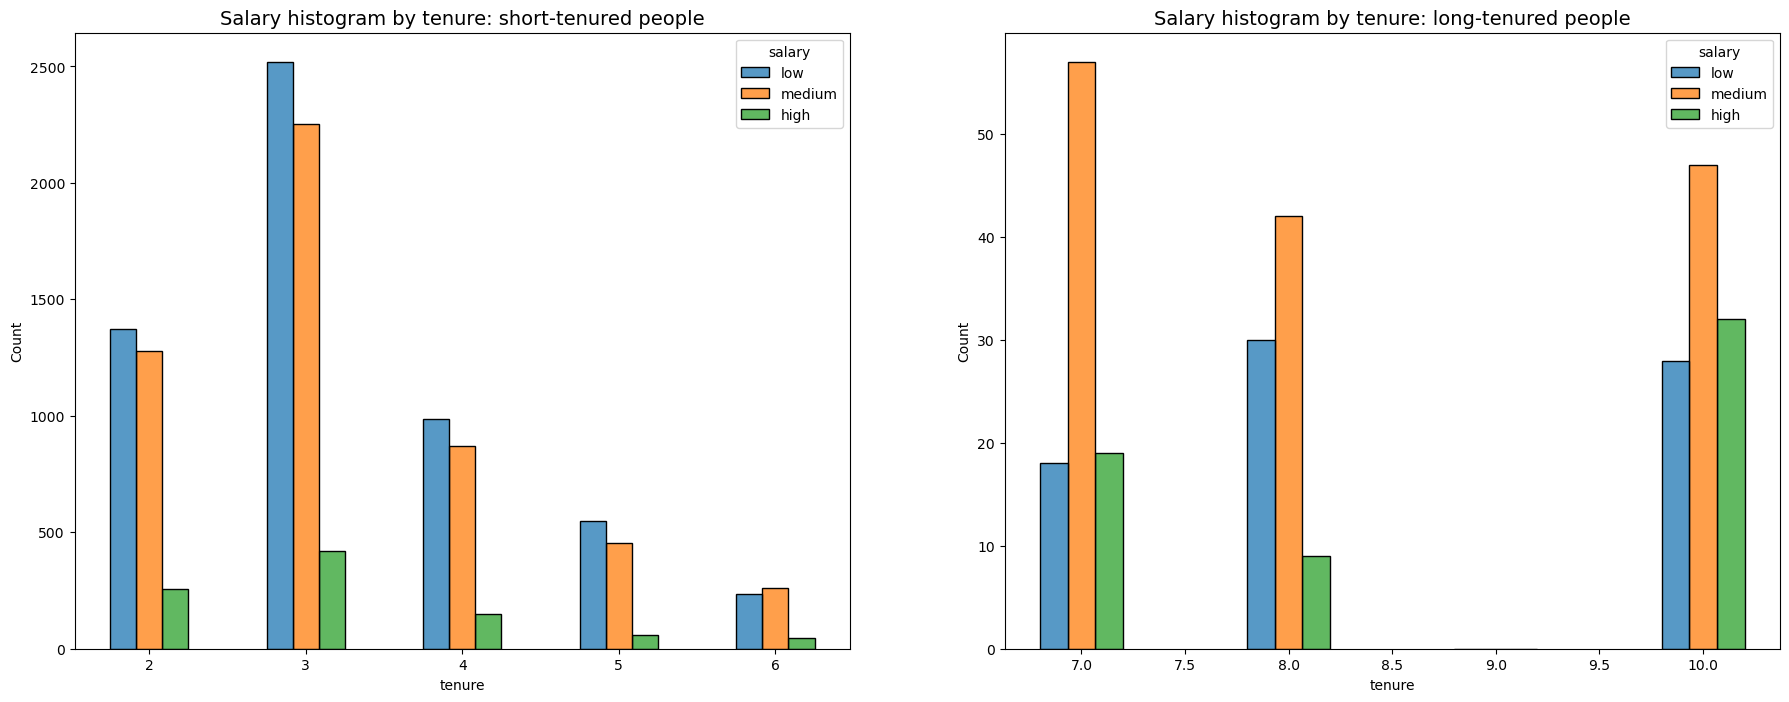

In [48]:
# Set figure and axes
fig, ax = plt.subplots(1, 2, figsize = (22,8))

# Define short-tenured employees
tenure_short = df2[df2['tenure'] <= 6]

# Define long-tenured employees
tenure_long = df2[df2['tenure'] > 6]

# Plot short-tenured histogram
sns.histplot(data=tenure_short, x='tenure', hue='salary', discrete=1, 
             hue_order=['low', 'medium', 'high'], multiple='dodge', shrink=.5, ax=ax[0])
ax[0].set_title('Salary histogram by tenure: short-tenured people', fontsize='14')

#Plot long-tenured histogram
sns.histplot(data = tenure_long, x = 'tenure', hue = 'salary', discrete = 1,
             hue_order= ['low', 'medium', 'high'], multiple = 'dodge', shrink = 0.4, ax = ax[1])
ax[1].set_title('Salary histogram by tenure: long-tenured people', fontsize = '14')

plt.show()

The plots above show that long-tenured employees were not disproportionately comprised of higher-paid employees. 

Now, I want to examine whether employees who worked longer hours were promoted in the last 5 years.

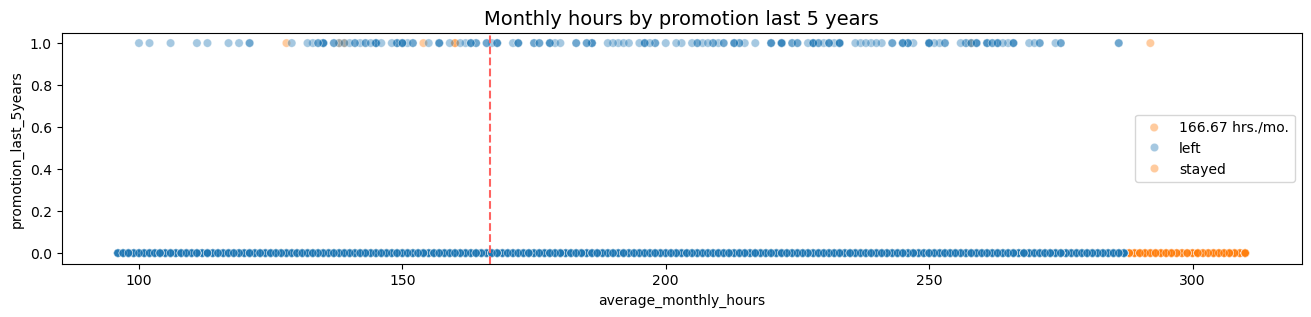

In [49]:
# Scatterplot of Average Monthly Hours per employee by whether they were promoted in the last 5 years
plt.figure(figsize=(16, 3))
sns.scatterplot(data=df2, x='average_monthly_hours', y='promotion_last_5years', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by promotion last 5 years', fontsize='14');

The plot above shows the following:

* Very few employees who were promoted in the last five years left.
* Very few employees who worked the most hours were promoted.
* Of all the employees that didn't get promoted in the last five years, all of those who left were working the longest hours.

Next, I want to check the number of employees per department.

In [50]:
# Number of Employees per Department
df2['department'].value_counts()

department
sales          3239
technical      2244
support        1821
IT              976
RandD           694
product_mng     686
marketing       673
accounting      621
hr              601
management      436
Name: count, dtype: int64

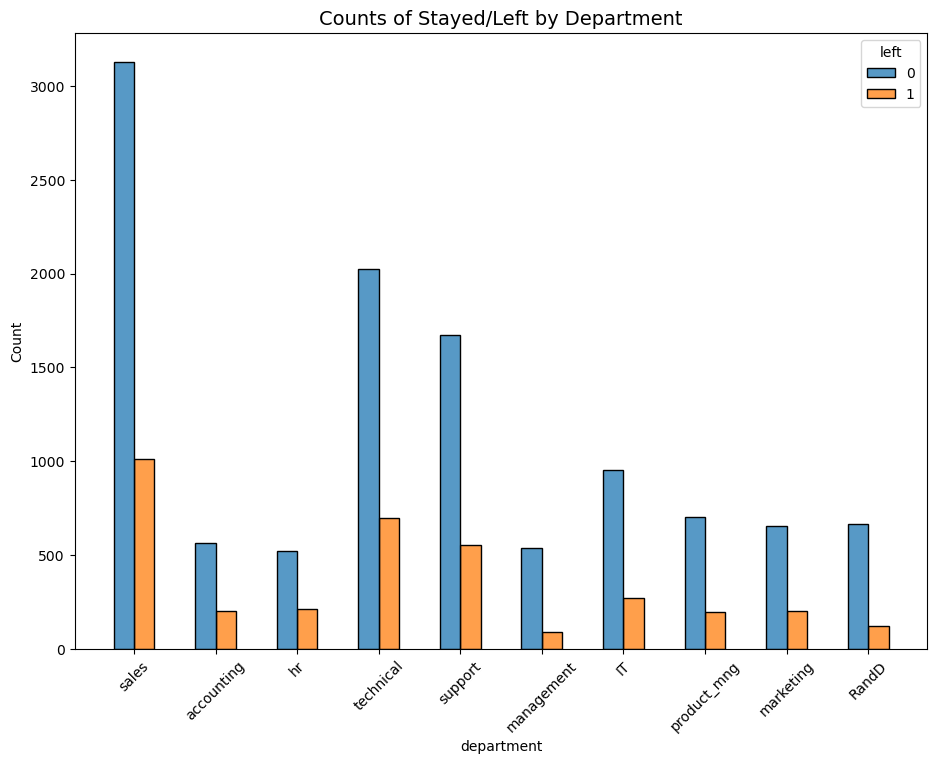

In [51]:
#Stacked Histogram showing number of employees by department, comparing those who left with those who stayed
plt.figure(figsize=(11,8))
sns.histplot(data=df1, x='department', hue='left', discrete=1, 
             hue_order=[0, 1], multiple='dodge', shrink=.5)
plt.xticks(rotation=45)
plt.title('Counts of Stayed/Left by Department', fontsize=14);

This histogram helps determine a lack of significance to whether employee turnover has anything to do with which department the employees came from.


Finally, I will create a Correlation Heatmap to identify any strongrelationships between variables.

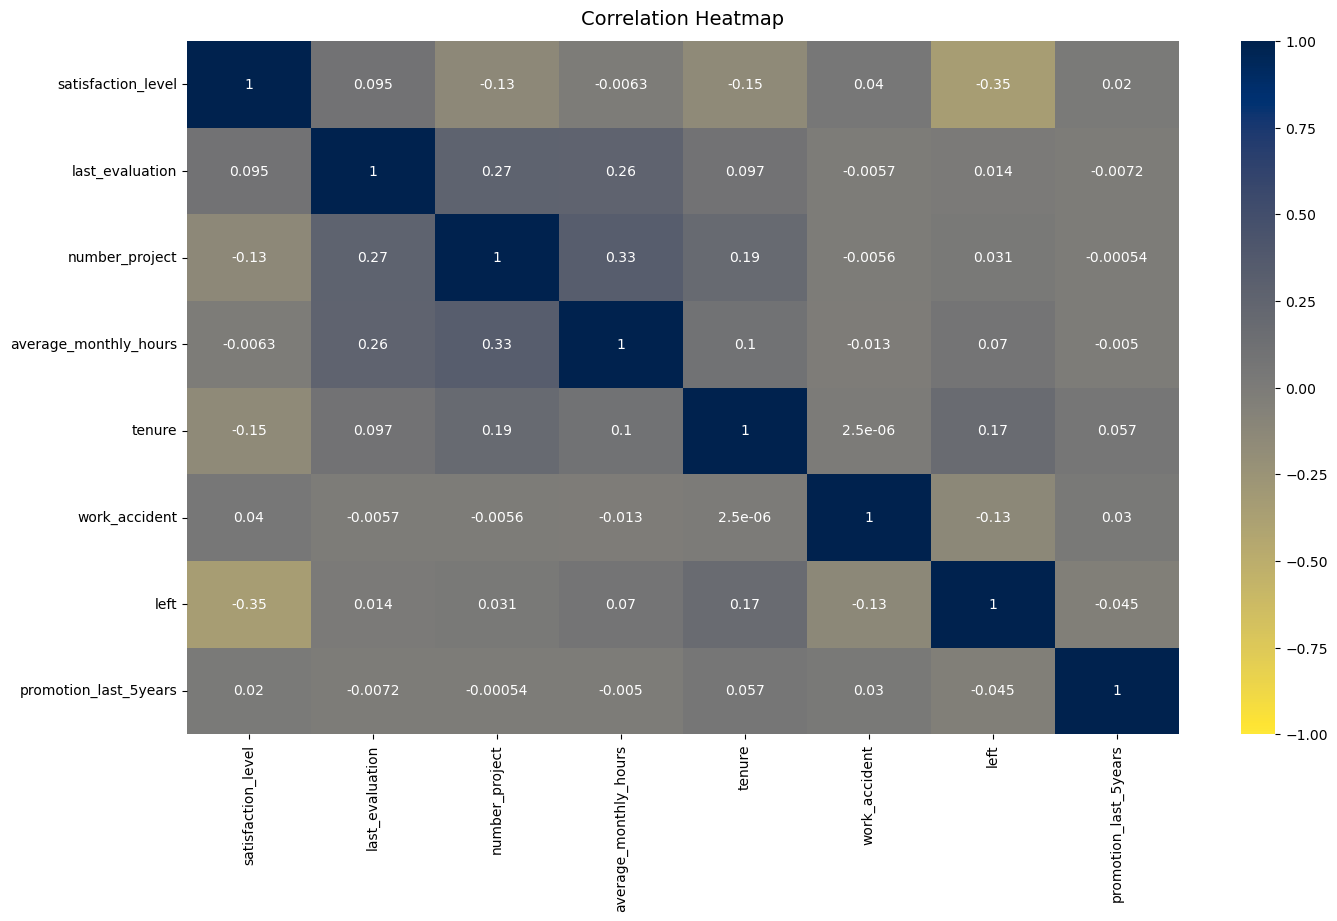

In [54]:
# Correlation Heatmap of every numeric variable
corr_matrix = df2.select_dtypes(include='number').corr()


plt.figure(figsize=(16, 9))
heatmap = sns.heatmap(corr_matrix, vmin=-1, vmax=1, annot=True, cmap=sns.color_palette("cividis_r", as_cmap=True))
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':14}, pad=12);

The correlation heatmap confirms that the number of projects, monthly hours, and evaluation scores all have some positive correlation with each other, and whether an employee leaves is negatively correlated with their satisfaction level. These correlations are not high enough to break the multicollinearity assumption if I end up using Logistic and/or Linear Regression models.

### Insights

It appears that employees are leaving the company as a result of poor management. Leaving is tied to longer working hours, numerous projects, and generally lower satisfaction levels. This could be compounded upon by how ungratified their work is having not recieved promotions or good evaluation scores. here's a sizeable group of employees at this company who are probably burned out. On a positive note, it also appears that if an employee has spent more than six years at the company, they tend not to leave.

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





💭
### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?
- Which independent variables did you choose for the model and why?
- Are each of the assumptions met?
- How well does your model fit the data?
- Can you improve it? Is there anything you would change about the model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

The goal for this project is to predict whether an employee is going to leave the company, which is a categorical outcome variable. This means the task will be classification, specifically binary classification since the `left` variable is either a `0 (indicating an employee didn't leave)` or a `1 (indicating an employee left)`

### Identify the types of models most appropriate for this task.

The models suitible for the task are as follows:

* Decision Tree
* Random Forest 
* Logistic Regression Model

I will try all of them and determine which will be the champion model to use and determine why employee turnover rate might be so high.

### Modeling

#### Logistic Regression

Before building the model, encoding must be done on the two categorical variables: `department` and `salary`.

In [55]:
# Copy the dataframe
df_enc = df2.copy()

# Encode the `salary` column as an ordinal numeric category
df_enc['salary'] = (
    df_enc['salary'].astype('category')
    .cat.set_categories(['low', 'medium', 'high'])
    .cat.codes
)

# Dummy encode the `department` column
df_enc = pd.get_dummies(df_enc, drop_first=False)

# Display the new dataframe
df_enc.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,1,0,1,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False


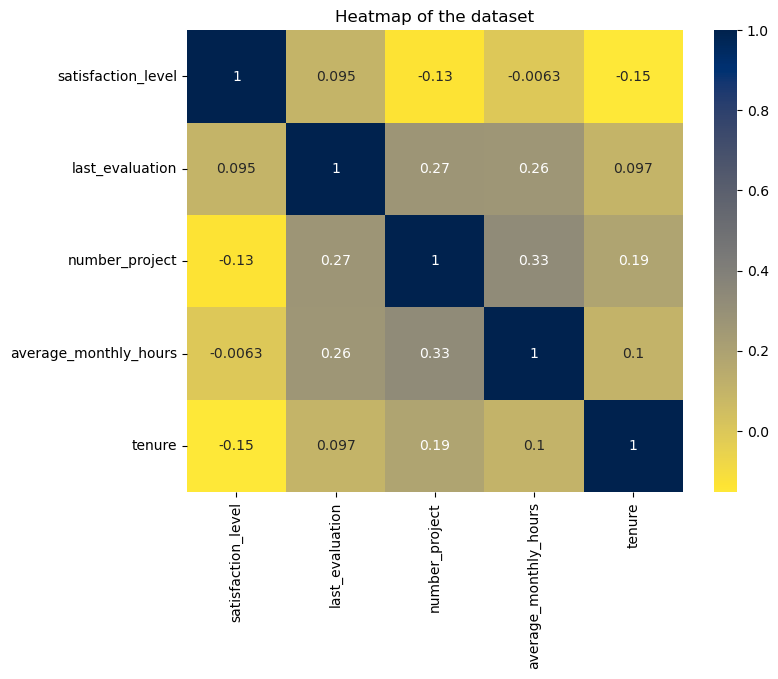

In [56]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_enc[['satisfaction_level', 'last_evaluation', 'number_project', 'average_monthly_hours', 'tenure']]
            .corr(), annot=True, cmap="cividis_r")
plt.title('Heatmap of the dataset')
plt.show()

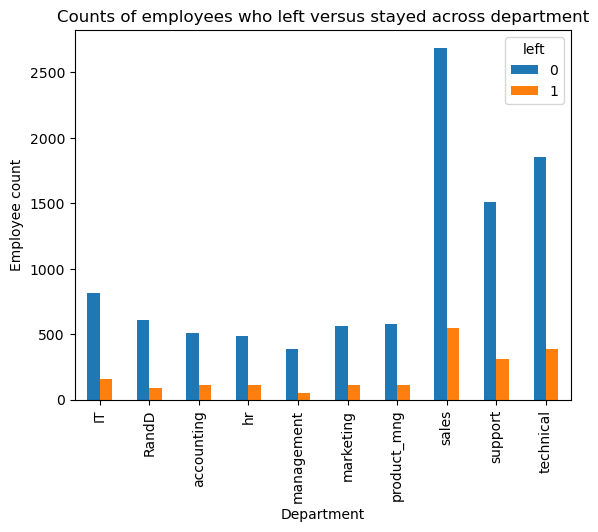

In [57]:
# In the legend, 0 (blue color) represents employees who did not leave, 1 (orange color) represents employees who left
pd.crosstab(df2['department'], df2['left']).plot(kind ='bar',color=['tab:blue', 'tab:orange'])
plt.title('Counts of employees who left versus stayed across department')
plt.ylabel('Employee count')
plt.xlabel('Department')
plt.show()

Since logistic regression is quite sensitive to outliers, it would be a good idea at this stage to remove the outliers in the `tenure` column that were identified earlier.

In [58]:
upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

# Select rows without outliers in `tenure` and save resulting dataframe in a new variable
df_logreg = df_enc[(df_enc['tenure'] >= lower_limit) & (df_enc['tenure'] <= upper_limit)]

# Display first few rows of new dataframe
df_logreg.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
5,0.41,0.50,2,153,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False


In [59]:
# Isolate the outcome variable
y = df_logreg['left']

# Display first few rows of the outcome variable
y.head() 

0    1
2    1
3    1
4    1
5    1
Name: left, dtype: int64

In [60]:
# Selecting all features besides target variable
X = df_logreg.drop('left', axis=1)

# Display the first few rows of the selected features 
X.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,0,0,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,0,0,False,False,False,False,False,False,False,True,False,False
5,0.41,0.50,2,153,3,0,0,0,False,False,False,False,False,False,False,True,False,False


In [61]:
# Split the data into training set and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

# Construct a logistic regression model and fit it to the training dataset
log_clf = LogisticRegression(random_state=42, max_iter=500).fit(X_train, y_train)

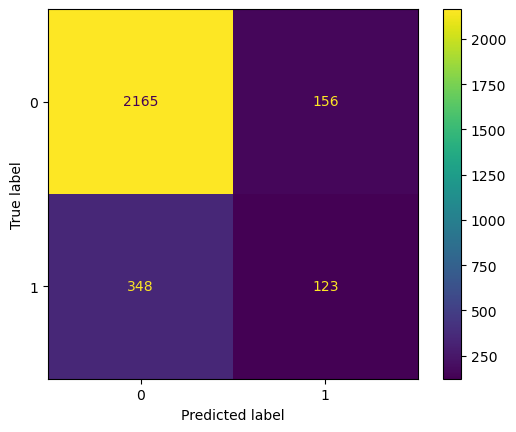

In [62]:
# Use the logistic regression model to get predictions on the test set
y_pred = log_clf.predict(X_test)

# Compute values for confusion matrix
log_cm = confusion_matrix(y_test, y_pred, labels=log_clf.classes_)

# Create display of confusion matrix
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, 
                                  display_labels=log_clf.classes_)

# Plot confusion matrix
log_disp.plot(values_format='')

# Display plot
plt.show()

The upper-left quadrant displays the number of true negatives. The upper-right quadrant displays the number of false positives. The bottom-left quadrant displays the number of false negatives. The bottom-right quadrant displays the number of true positives.

- True negatives: The number of people who did not leave that the model accurately predicted did not leave.

- False positives: The number of people who did not leave the model inaccurately predicted as leaving.

- False negatives: The number of people who left that the model inaccurately predicted did not leave

- True positives: The number of people who left the model accurately predicted as leaving

A perfect model would yield all true negatives and true positives, and no false negatives or false positives.

I will now create a classification report that includes precision, recall, f1-score, and accuracy metrics to evaluate the performance of the logistic regression model.

Before creating the report, check the class balance in the data. In other words, check the value counts in the `left` column. Since this is a binary classification task, the class balance informs the way you interpret accuracy metrics.

In [63]:
df_logreg['left'].value_counts(normalize=True)

left
0    0.831468
1    0.168532
Name: proportion, dtype: float64

There is an approximately 83%-17% split. So the data is not perfectly balanced, but it is not too imbalanced.In this case, I will use this data without modifying the class balance and continue evaluating the model.

In [64]:
# Create classification report for logistic regression model
target_names = ['Predicted would not leave', 'Predicted would leave']
print(classification_report(y_test, y_pred, target_names=target_names))

                           precision    recall  f1-score   support

Predicted would not leave       0.86      0.93      0.90      2321
    Predicted would leave       0.44      0.26      0.33       471

                 accuracy                           0.82      2792
                macro avg       0.65      0.60      0.61      2792
             weighted avg       0.79      0.82      0.80      2792



The classification report above shows that the logistic regression model achieved a precision of 79%, recall of 82%, f1-score of 80% (all weighted averages), and accuracy of 82%. However, the goal is to predict employees who leave, which has scores that are significantly lower.

### Tree-Based Models

This include Decision trees and Random Forest

#### Decision Tree

In [65]:
# Isolate the outcome variable
y = df_enc['left']

# Select the features
X = df_enc.drop('left', axis=1)

In [66]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

In [70]:
# Instantiate model
tree = DecisionTreeClassifier(random_state=0)

# Assign a dictionary of hyperparameters to search over
cv_params = {'max_depth':[4, 6, 8, None],
             'min_samples_leaf': [2, 5, 1],
             'min_samples_split': [2, 4, 6]
             }

# Assign a dictionary of scoring metrics to capture
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Instantiate GridSearch
tree1 = GridSearchCV(tree, cv_params, scoring=scoring, cv=4, refit='roc_auc')

In [71]:
%%time
tree1.fit(X_train, y_train)

CPU times: user 3.22 s, sys: 94.6 ms, total: 3.31 s
Wall time: 3.4 s


,estimator,DecisionTreeC...andom_state=0)
,param_grid,"{'max_depth': [4, 6, ...], 'min_samples_leaf': [2, 5, ...], 'min_samples_split': [2, 4, ...]}"
,scoring,"{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall', ...}"
,n_jobs,None
,refit,'roc_auc'
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [72]:
# Check best parameters
tree1.best_params_

{'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 2}

In [74]:
# Check best AUC score on CV
tree1.best_score_

0.969819392792457

In order to extract the results easily, I'm going to create a function that gets all the results from the grid search.

In [75]:
###Function for score extraction from grid search

def make_results(model_name:str, model_object, metric:str):
    '''
    Arguments:
        model_name (string): what you want the model to be called in the output table
        model_object: a fit GridSearchCV object
        metric (string): precision, recall, f1, accuracy, or auc
  
    Returns a pandas dataframe with the F1, recall, precision, accuracy, and auc scores
    for the model with the best mean 'metric' score across all validation folds.  
    '''

    metric_dict = {'auc': 'mean_test_roc_auc',
                   'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy'
                  }

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(metric) score
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    # Extract Accuracy, precision, recall, and f1 score from that row
    auc = best_estimator_results.mean_test_roc_auc
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy
  
    # Create table of results
    table = pd.DataFrame()
    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy],
                          'auc': [auc]
                        })
  
    return table

In [76]:
# Get all CV scores
tree1_cv_results = make_results('decision tree cv', tree1, 'auc')
tree1_cv_results

,model,precision,recall,F1,accuracy,auc
0,decision tree cv,0.914552,0.916949,0.915707,0.971978,0.969819


All of these scores from the Decision Tree model are strong indicators of good model performance. However, I must note that decision trees are quite susceptible to overfitting. This is not an issue for Random Forest, which is what i will build next.

#### Random Forest

In [89]:
# Instantiate model
rf = RandomForestClassifier(random_state=0)

# Assign a dictionary of hyperparameters to search over
cv_params = {'max_depth': [3,5, None], 
             'max_features': [1.0],
             'max_samples': [0.7, 1.0],
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'n_estimators': [300, 500],
             }  

# Assign a dictionary of scoring metrics to capture
scoring = {'accuracy':'accuracy',
           'precision':'precision',
           'recall':'recall',
           'f1':'f1',
           'roc_auc':'roc_auc'}

# Instantiate GridSearch
rf1 = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='roc_auc')

In [90]:
%%time
rf1.fit(X_train, y_train) 

CPU times: user 16min 15s, sys: 7.91 s, total: 16min 23s
Wall time: 16min 43s


,estimator,RandomForestC...andom_state=0)
,param_grid,"{'max_depth': [3, 5, ...], 'max_features': [1.0], 'max_samples': [0.7, 1.0], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,"{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall', ...}"
,n_jobs,None
,refit,'roc_auc'
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


In [95]:
# Check best AUC score on CV
rf1.best_score_

0.9804250949807172

In [96]:
# Check best params
rf1.best_params_

{'max_depth': 5,
 'max_features': 1.0,
 'max_samples': 0.7,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'n_estimators': 500}

In [97]:
# Get all CV scores
rf1_cv_results = make_results('random forest cv', rf1, 'auc')
print(tree1_cv_results)
print(rf1_cv_results)

              model  precision    recall        F1  accuracy       auc
0  decision tree cv   0.914552  0.916949  0.915707  0.971978  0.969819
              model  precision    recall        F1  accuracy       auc
0  random forest cv   0.950023  0.915614  0.932467  0.977983  0.980425


The evaluation scores of the random forest model are better than those of the decision tree model, with the exception of recall (the recall score of the random forest model is approximately 0.001 lower, which is negligible). This indicates that the random forest model mostly outperforms the decision tree model.

Now, I'm going to evaluate the final model on the test set.

First, I will define another function that gets all the scores from a model's predictions.

In [98]:
### Function that gets all the scores from a model's prediction
def get_scores(model_name:str, model, X_test_data, y_test_data):
    '''
    Generate a table of test scores.

    In: 
        model_name (string):  How you want your model to be named in the output table
        model:                A fit GridSearchCV object
        X_test_data:          numpy array of X_test data
        y_test_data:          numpy array of y_test data

    Out: pandas df of precision, recall, f1, accuracy, and AUC scores for your model
    '''

    preds = model.best_estimator_.predict(X_test_data)

    auc = roc_auc_score(y_test_data, preds)
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision], 
                          'recall': [recall],
                          'f1': [f1],
                          'accuracy': [accuracy],
                          'AUC': [auc]
                         })
  
    return table

In [99]:
# Get predictions on test data
rf1_test_scores = get_scores('random forest1 test', rf1, X_test, y_test)
rf1_test_scores

,model,precision,recall,f1,accuracy,AUC
0,random forest1 test,0.964211,0.919679,0.941418,0.980987,0.956439


The test scores are very similar to the validation scores, which is good. This appears to be a strong model. Since this test set was only used for this model, I am confident that my model's performance on this data is representative of how it will perform on new, unseeen data.

#### Feature Engineering

I want to attempt to improve upon both tree-based models by performing feature engineering. I'm going to first remove `satisfaction level` and then create a new binary variable called `overworked`.

In [100]:
# Drop `satisfaction_level` and save resulting dataframe in new variable
df3 = df_enc.drop('satisfaction_level', axis=1)

# Display first few rows of new dataframe
df3.head()

,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
1,0.86,5,262,6,0,1,0,1,False,False,False,False,False,False,False,True,False,False
2,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False
3,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False
4,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False


In [101]:
# Create `overworked` column. For now, it's identical to average monthly hours.
df3['overworked'] = df3['average_monthly_hours']

# Inspect max and min average monthly hours values
print('Max hours:', df3['overworked'].max())
print('Min hours:', df3['overworked'].min())

Max hours: 310
Min hours: 96


166.67 is approximately the average number of monthly hours for someone who works 50 weeks per year, 5 days per week, 8 hours per day. 

I will define being overworked as working more than 175 hours per month on average.

To make the `overworked` column binary, I will reassign the column using a boolean mask
- `df3['overworked'] > 175` creates a series of booleans, consisting of `True` for every value > 175 and `False` for every values ≤ 175
- `.astype(int)` converts all `True` to `1` and all `False` to `0` 

In [103]:
# Define `overworked` as working > 175 hrs/week
df3['overworked'] = (df3['overworked'] > 175).astype(int)

# Display first few rows of new column
df3['overworked'].head()

0    0
1    0
2    0
3    0
4    0
Name: overworked, dtype: int64

Now, I also want to drop `Average Monthly Hours`.

In [104]:
# Drop the `average_monthly_hours` column
df3 = df3.drop('average_monthly_hours', axis=1)

# Display first few rows of resulting dataframe
df3.head()

,last_evaluation,number_project,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,overworked
0,0.53,2,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False,0
1,0.86,5,6,0,1,0,1,False,False,False,False,False,False,False,True,False,False,0
2,0.88,7,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False,0
3,0.87,5,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False,0
4,0.52,2,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False,0


In [105]:
# Isolate the outcome variable
y = df3['left']

# Select the features
X = df3.drop('left', axis=1)

In [106]:
# Create test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

#### Decision Tree -  Round 2

In [110]:
# Instantiate model
tree = DecisionTreeClassifier(random_state=0)

# Assign a dictionary of hyperparameters to search over
cv_params = {'max_depth':[4, 6, 8, None],
             'min_samples_leaf': [2, 5, 1],
             'min_samples_split': [2, 4, 6]
             }

# Assign a dictionary of scoring metrics to capture
scoring = {'accuracy':'accuracy',
           'precision':'precision',
           'recall':'recall',
           'f1':'f1',
           'roc_auc':'roc_auc'}

# Instantiate GridSearch
tree2 = GridSearchCV(tree, cv_params, scoring=scoring, cv=4, refit='roc_auc')

In [111]:
%%time
tree2.fit(X_train, y_train)

CPU times: user 2.76 s, sys: 55.6 ms, total: 2.81 s
Wall time: 2.86 s


,estimator,DecisionTreeC...andom_state=0)
,param_grid,"{'max_depth': [4, 6, ...], 'min_samples_leaf': [2, 5, ...], 'min_samples_split': [2, 4, ...]}"
,scoring,"{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall', ...}"
,n_jobs,None
,refit,'roc_auc'
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [112]:
# Check best params
tree2.best_params_

{'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 2}

In [113]:
# Check best AUC score on CV
tree2.best_score_

0.9564598419138554

This model performs very well, even without satisfaction levels and detailed hours worked data.

In [114]:
# Get all CV scores
tree2_cv_results = make_results('decision tree2 cv', tree2, 'auc')
print(tree1_cv_results)
print(tree2_cv_results)

              model  precision    recall        F1  accuracy       auc
0  decision tree cv   0.914552  0.916949  0.915707  0.971978  0.969819
               model  precision    recall        F1  accuracy      auc
0  decision tree2 cv   0.844484  0.898862  0.870651  0.955632  0.95646


When looking at the other scores, some of them ended up falling. This is to be expected given fewer features were taken into account in this round of the model. Still, the scores are very good.

#### Random forest - Round 2

In [116]:
# Instantiate model
rf = RandomForestClassifier(random_state=0)

# Assign a dictionary of hyperparameters to search over
cv_params = {'max_depth': [3,5, None], 
             'max_features': [1.0],
             'max_samples': [0.7, 1.0],
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'n_estimators': [300, 500],
             }  

# Assign a dictionary of scoring metrics to capture
scoring = {'accuracy':'accuracy',
           'precision':'precision',
           'recall':'recall',
           'f1':'f1',
           'roc_auc':'roc_auc'}

# Instantiate GridSearch
rf2 = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='roc_auc')

In [117]:
%%time
rf2.fit(X_train, y_train)

CPU times: user 11min 24s, sys: 5.83 s, total: 11min 29s
Wall time: 11min 36s


,estimator,RandomForestC...andom_state=0)
,param_grid,"{'max_depth': [3, 5, ...], 'max_features': [1.0], 'max_samples': [0.7, 1.0], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,"{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall', ...}"
,n_jobs,None
,refit,'roc_auc'
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [120]:
# Check best params
rf2.best_params_

{'max_depth': 5,
 'max_features': 1.0,
 'max_samples': 1.0,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'n_estimators': 300}

In [121]:
# Check best AUC score on CV
rf2.best_score_

0.9626309300225087

In [122]:
# Get all CV scores
rf2_cv_results = make_results('random forest2 cv', rf2, 'auc')
print(tree2_cv_results)
print(rf2_cv_results)

               model  precision    recall        F1  accuracy      auc
0  decision tree2 cv   0.844484  0.898862  0.870651  0.955632  0.95646
               model  precision   recall        F1  accuracy       auc
0  random forest2 cv    0.84984  0.86133  0.855059  0.951517  0.962631


Again, the scores dropped slightly, but the Random Forest performs better than the Decision Tree if using AUC as the deciding metric. Thus, the Random Forest model is the champion model.

I will now score the champion model using the test data.

In [123]:
# Get predictions on test data
rf2_test_scores = get_scores('random forest2 test', rf2, X_test, y_test)
rf2_test_scores

,model,precision,recall,f1,accuracy,AUC
0,random forest2 test,0.826958,0.911647,0.86724,0.953636,0.936823


This seems to be a stable, well-performing final model.

I will now plot a confusion matrix to visualize how successful it is at predicting.

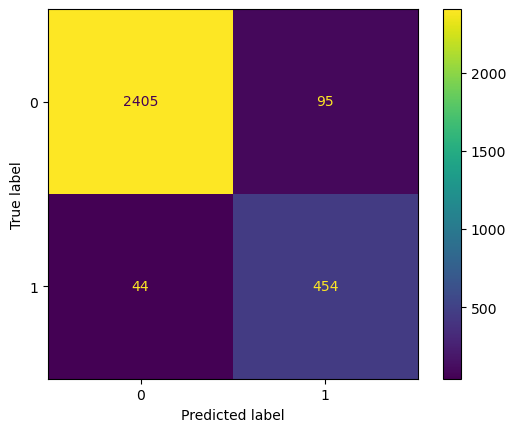

In [124]:
# Generate array of values for confusion matrix
preds = rf2.best_estimator_.predict(X_test)
cm = confusion_matrix(y_test, preds, labels=rf2.classes_)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=rf2.classes_)
disp.plot(values_format='');

The model predicts more false positives than false negatives, meaning some employees may be identified as at risk of quitting or getting fired, when that's actually not the case. Despite that, this is still a strong model.

For exploratory purpose, I want to inspect the splits of the Decision Tree model and the most important features in the Random Forest model.

#### Decision Tree Splits

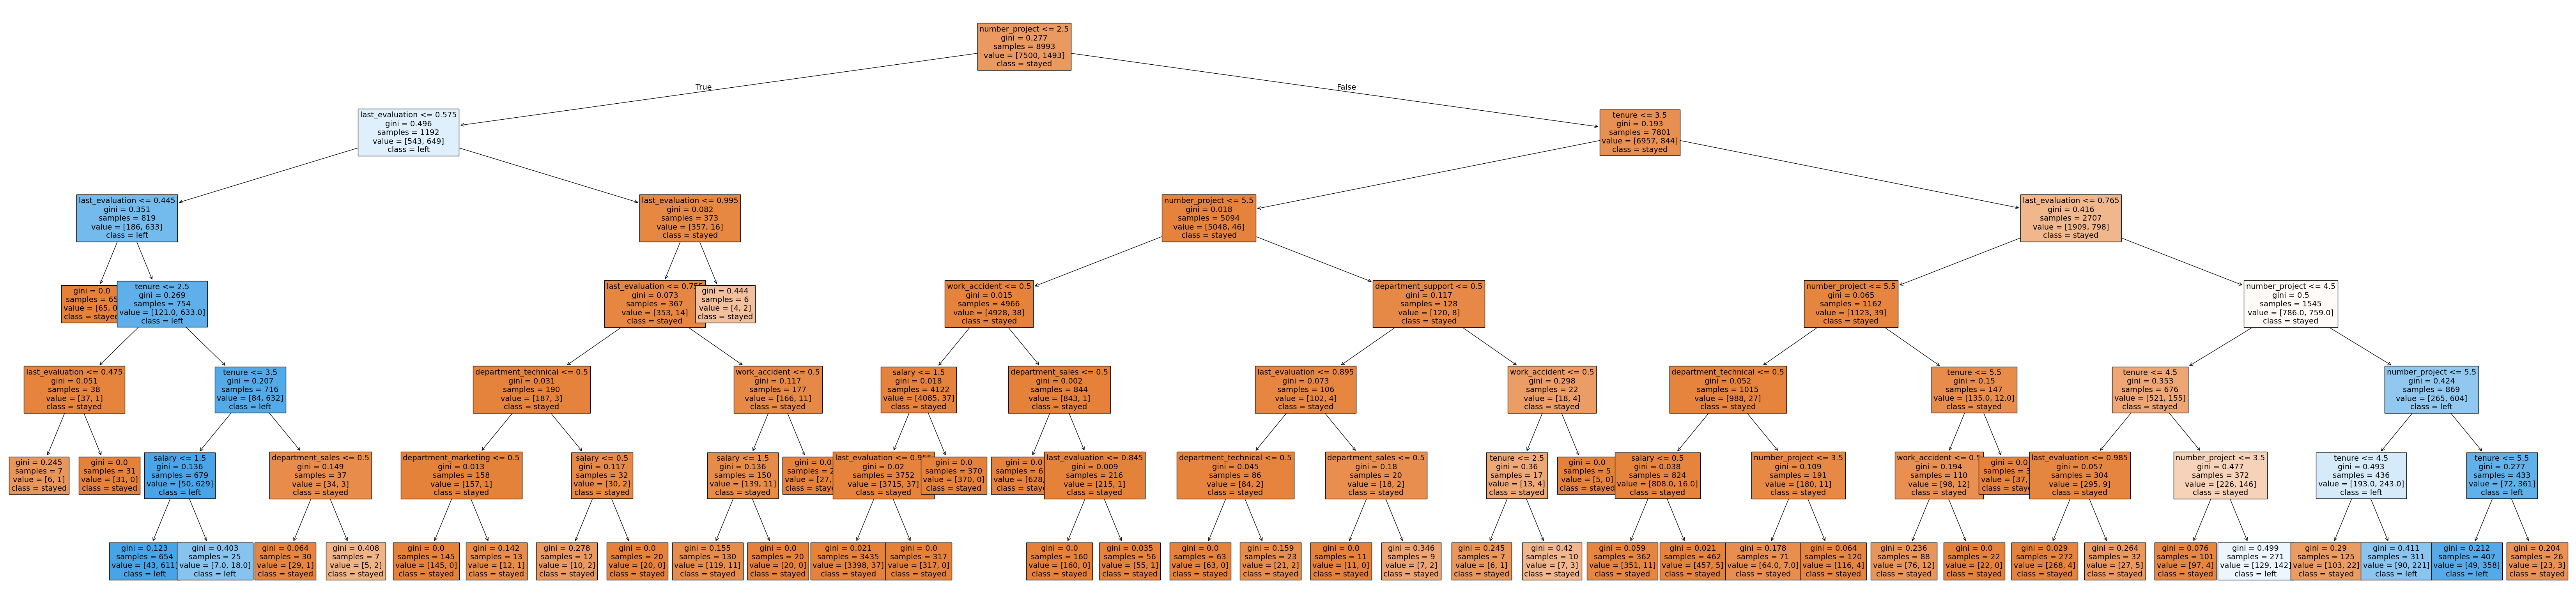

In [125]:
# Plot the tree
plt.figure(figsize=(85,20))
plot_tree(tree2.best_estimator_, max_depth=6, fontsize=14, feature_names=X.columns, 
          class_names={0:'stayed', 1:'left'}, filled=True);
plt.show()

#### Decision Tree Feature Importance

In [126]:
#tree2_importances = pd.DataFrame(tree2.best_estimator_.feature_importances_, columns=X.columns)
tree2_importances = pd.DataFrame(tree2.best_estimator_.feature_importances_, 
                                 columns=['gini_importance'], 
                                 index=X.columns
                                )
tree2_importances = tree2_importances.sort_values(by='gini_importance', ascending=False)

# Only extract the features with importances > 0
tree2_importances = tree2_importances[tree2_importances['gini_importance'] != 0]
tree2_importances

,gini_importance
last_evaluation,0.356608
number_project,0.350883
tenure,0.288319
salary,0.001730
work_accident,0.000790
department_sales,0.000681
department_technical,0.000489
department_support,0.000423
department_marketing,0.000079


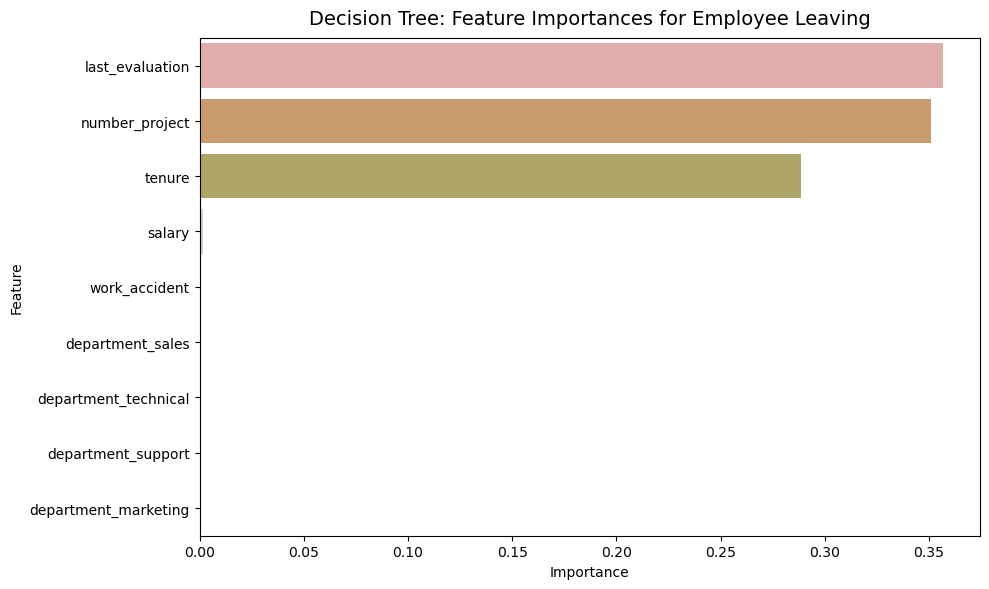

In [137]:
feature_colors = {
    "last_evaluation": "#e9a3a3",      # soft pink
    "number_project": "#d89b5f",       # muted orange
    "tenure": "#b9ad5a",               # olive
    "overworked": "#9fb25a",           # green
    "department_support": "#cfcfcf",
    "salary": "#cfcfcf",
    "department_sales": "#cfcfcf",
    "department_technical": "#cfcfcf",
    "work_accident": "#cfcfcf",
    "department_IT": "#cfcfcf",
    "department_marketing": "#cfcfcf"
}

# Build color list in correct order
bar_colors = [
    feature_colors[feature]
    for feature in tree2_importances.index
]

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x=tree2_importances["gini_importance"],
    y=tree2_importances.index,
    orient="h",
    palette=bar_colors,
    hue = tree2_importances.index,
    errorbar=None
)

plt.title(
    "Decision Tree: Feature Importances for Employee Leaving",
    fontsize=14,
    pad=10
)
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

The barplot above shows that in this Decision Tree model, `last_evaluation`, `number_project`, `tenure`, and `overworked` have the highest importance, in that order. These variables are most helpful in predicting the outcome variable, `left`.

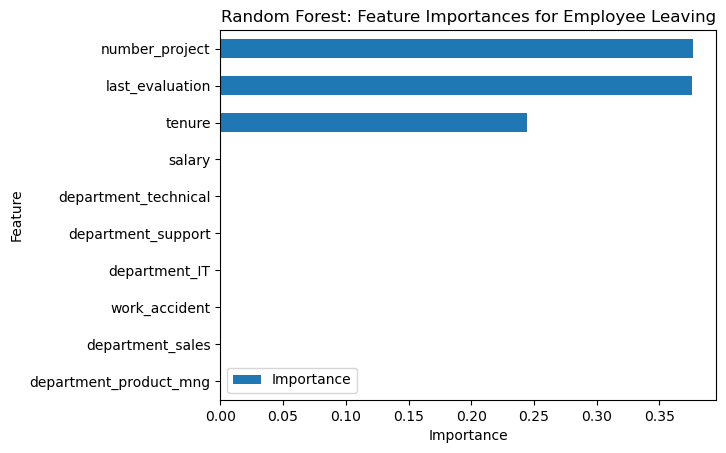

In [128]:
# Get feature importances
feat_impt = rf2.best_estimator_.feature_importances_

# Get indices of top 10 features
ind = np.argpartition(rf2.best_estimator_.feature_importances_, -10)[-10:]

# Get column labels of top 10 features 
feat = X.columns[ind]

# Filter `feat_impt` to consist of top 10 feature importances
feat_impt = feat_impt[ind]

y_df = pd.DataFrame({"Feature":feat,"Importance":feat_impt})
y_sort_df = y_df.sort_values("Importance")
fig = plt.figure()
ax1 = fig.add_subplot(111)

y_sort_df.plot(kind='barh',ax=ax1,x="Feature",y="Importance")

ax1.set_title("Random Forest: Feature Importances for Employee Leaving", fontsize=12)
ax1.set_ylabel("Feature")
ax1.set_xlabel("Importance")

plt.show()

The plot above shows that in this Random Forest model, `last_evaluation`, `number_project`, `tenure`, and `overworked` have the highest importance, in that order. These variables are most helpful in predicting the outcome variable, `left`, and they are the same as the ones used by the Decision Tree model.

# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
- What business recommendations do you propose based on the models built?
- What potential recommendations would you make to your manager/company?
- Do you think your model could be improved? Why or why not? How?
- Given what you know about the data and the models you were using, what other questions could you address for the team?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



Double-click to enter your responses here.

## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Summary of model results

#### Logistic Regression

The Logistic Regression model achieved precision of 80%, recall of 83%, f1-score of 80% (all weighted averages), and accuracy of 83%, on the test set.

#### Tree-based Machine Learning

After conducting feature engineering, the Decision Tree model achieved AUC of 93.8%, precision of 87.0%, recall of 90.4%, f1-score of 88.7%, and accuracy of 96.2%, on the test set. The Random Forest modestly outperformed the decision tree model.

### Conclusion, Recommendations, Next Steps

The models and the feature importances extracted from the models confirm that employees at the company are overworked.

To retain employees, the following recommendations could be presented to the stakeholders:

- Cap the number of projects that employees can work on.

- Consider promoting employees who have been with the company for atleast four years, or conduct further investigation about why four-year tenured employees are so dissatisfied.

- Either reward employees for working longer hours, or don't require them to do so.

- If employees aren't familiar with the company's overtime pay policies, inform them about this. If the expectations around workload and time off aren't explicit, make them clear.

- Hold company-wide and within-team discussions to understand and address the company work culture, across the board and in specific contexts.

- High evaluation scores should not be reserved for employees who work 200+ hours per month. Consider a proportionate scale for rewarding employees who contribute more/put in more effort.

#### Next Steps

It may be justified to still have some concern about data leakage. It could be prudent to consider how predictions change when `last_evaluation` is removed from the data. It's possible that evaluations aren't performed very frequently, in which case it would be useful to be able to predict employee retention without this feature. It's also possible that the evaluation score determines whether an employee leaves or stays, in which case it could be useful to pivot and try to predict performance score. The same could be said for satisfaction score. 

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.